In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
def contar_palabra_clave(archivo, palabra_clave, case_sensitive=False, como_subcadena=True):
    try:
        with open(archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()
    except: 
        return 0
    
    if not case_sensitive:
        contenido = contenido.lower()
        palabra_clave = palabra_clave.lower()
    
    if como_subcadena:
        # Busca la palabra como subcadena (ej: "wind" encuentra "windspeed")
        return contenido.count(palabra_clave)
    else:
        # Busca la palabra exacta (no como parte de otra palabra)
        patron = r'\b' + re.escape(palabra_clave) + r'\b'
        return len(re.findall(patron, contenido))

def agregar_palabra_clave(df, carpeta, palabra_clave, case_sensitive=False, como_subcadena=True):    
    # Obtener lista de archivos .md en la carpeta
    archivos = [f for f in os.listdir(carpeta) if f.endswith('.md')]    
    # Si no hay DataFrame, creamos uno con los nombres de archivo como índice
    if df is None: 
        df = pd.DataFrame(index=archivos)    
    # Calcular los conteos para cada archivo
    conteos = []
    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        conteo = contar_palabra_clave(ruta, palabra_clave, case_sensitive, como_subcadena)
        conteos.append(conteo)    
    # Agregar la columna (nombre = palabra_clave)
    df[palabra_clave] = conteos    
    return df
palabras=["WCB","warm conveyor belt","sting jet","WJ",]
# palabras=["KDE","PDF","extratropical","asymmetry","south america","MEOF","histogram","windspeed","topography"]
if __name__ == "__main__":
    carpeta_md = "./files_MD"   # Cambia por tu ruta    
    # Inicializamos el DataFrame vacío
    df_resultados = None      
    # Ejemplo 1: Buscar "wind" dentro de palabras más grandes (como_subcadena=True)
    # df_resultados = agregar_palabra_clave(df_resultados, carpeta_md, "wind", case_sensitive=False, como_subcadena=True)    
    # Ejemplo 2: Buscar "wind speed" como frase exacta (como_subcadena=False para palabra exacta)
    # df_resultados = agregar_palabra_clave(df_resultados, carpeta_md, "wind speed", case_sensitive=False, como_subcadena=True)    
    # # # Ejemplo 3: Buscar "windspeed" exactamente
    # df_resultados = agregar_palabra_clave(df_resultados, carpeta_md, "windspeed", case_sensitive=False, como_subcadena=True)
    for palabra in palabras:
        df_resultados = agregar_palabra_clave(df_resultados, carpeta_md, palabra, case_sensitive=False, como_subcadena=True)

In [63]:
df_resultados['suma']=df_resultados.sum(axis=1)

WCB
warm conveyor belt
sting jet
WJ


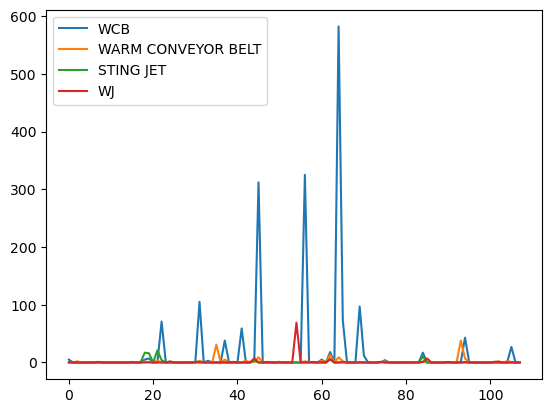

In [64]:
for var in df_resultados.columns[:-1]:
    print(var)
    plt.plot(range(len(df_resultados)),df_resultados[var],label=var.upper())
plt.legend()

In [67]:
var1=palabras[0]#'asymmetry'#"topography"#'WCB'#'histogram'
var2=palabras[1]#'suma'#'wind speed'
df_ordenado = df_resultados[
    (df_resultados[var1] > 1) & 
    (df_resultados[var2] > 0)
].sort_values(
    by=[var1,var2],
    ascending=[False, False]
)
df_ordenado.head(12)

,WCB,warm conveyor belt,sting jet,WJ,suma
heitmann2024lifecycle.md,582,9,0,0,591
catto2015front.md,325,2,0,0,327
oertel2021warm.md,312,9,0,0,321
flaounas2018heavy.md,105,3,1,0,109
schemm2014ccb.md,97,1,0,0,98
sawada2021heavy.md,73,2,1,0,76
coll2024lagrangian.md,43,7,1,0,51
portal2024linking.md,38,5,0,0,43
catto2010climate.md,27,1,0,0,28
catto2016extratropical.md,18,13,5,6,42


In [68]:
df_ordenado.head(12).index

Index(['heitmann2024lifecycle.md', 'catto2015front.md', 'oertel2021warm.md',
       'flaounas2018heavy.md', 'schemm2014ccb.md', 'sawada2021heavy.md',
       'coll2024lagrangian.md', 'portal2024linking.md', 'catto2010climate.md',
       'catto2016extratropical.md', 'clark2018sting.md',
       'gray2020prototype.md'],
      dtype='str')